# Understat Soccer Player Performance Analysis
## Sebastian Csizmazia

 --------------------------------------------------------------------------------------------------------------------------------------------------

Must run cell as the Understat API and Plotly are external libraries, and not native to the Python Runtime (Plotly is included in Conda).

In [ ]:
%pip install understatapi
%pip install plotly

 --------------------------------------------------------------------------------------------------------------------------------------------------
For this lab we are using [Understat](https://understat.com/league/EPL) to get player stats from the top 5 European football leagues from the past 10 years. From this dataset, we will player_name, games  time, goals, xG, and shots columns. The main point of this analysis will to be to visualize effectiveness of players throughout the stated leagues over the years. Whether it is the top goalscorers, or players with no goals, or even a random sample, these visualization(s) give insights into how efficiently and effectively players are converting shot attempts into goals.
<br><br>
As the code currently is, it shows visualizations of the EPL's 2024/25 seasons top 25 goalscorers goal coun ts to their seasonal xG. [Expected goals (xG)](https://en.wikipedia.org/wiki/Expected_goals) is a performance metric used to evaluate team and player performances. It can be used to represent the probability of a scoring opportunity that may result in a goal. xG values range from 0.0 to 1.0 (all though having a shot with an xG of 0 or 1 are <strong>EXTREMELY</strong> unlikely). Here is an example of xG:

<table>
    <thead>
      <tr>
        <th>xG Type</th>
        <th>Meaning</th>
        <th>Example</th>
        <th>Typical xG Value</th>
      </tr>
    </thead>
    <tbody>
      <tr class="high-xg">
        <td>High xG</td>
        <td>The shot had a high probability of being a goal. Usually from close range with a clear chance.</td>
        <td>A tap-in from 3 yards out</td>
        <td>0.9 (90%)</td>
      </tr>
      <tr class="low-xg">
        <td>Low xG</td>
        <td>The shot had a low probability of being a goal. Typically from distance or a tight angle under pressure.</td>
        <td>A shot from 30 yards out</td>
        <td>0.05 (5%)</td>
      </tr>
    </tbody>
  </table>
<br>

 --------------------------------------------------------------------------------------------------------------------------------------------------

First, the required libaries must be imported.

In [ ]:
from understatapi import UnderstatClient
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

To choose a league, set the `league` variable equal to one of `EPL`, `La_Liga`, `Bundesliga`, `Serie_A`, `Ligue_1`
<br><br>
To choose a season, set the `season` variable equal to one of `2014`, `2015`, `2016`, ..., `2023`, `2024`.
<br><br>
To choose how many players you want to view, change the `N` value to a valid non-negative integer.
<br><br>
To view the top `N` goal scorers of your chosen league & season, make sure `top_goalscorers = player_data.sort_values(by = 'goals', ascending = False).head(N)` is uncommented. If you want to view a random sample of players, make sure `top_goalscorers = player_data.sample(N)` is uncommented. Though an `N` value higher than ~50 is not recommended as the graph will be extremely cluttered and may cause performance issues.


<strong>(Note: String values must be EXACTLY the same i.e. include underscores and match capitalization) and only one</strong> `top_goalscorers` <strong>should be uncommented at a time.</strong>


In [ ]:
# Create UnderstatClient from Undertstat API (code is on their GitHub repo)
understat = UnderstatClient()

# Use one of EPL, La_Liga, Bundesliga, Serie_A, Ligue_1
league = "EPL"
# Enter full year 20## in range 2014-2024
season = "2024"
# Choose the N 'top goalscorers' below
N = 25

league_player_data = understat.league(league = league).get_player_data(season = season)

# Make league name display nicer
league = league.replace("_", " ")

player_data = pd.DataFrame(league_player_data)
print(f"{league} has {player_data.shape[0]} players.\n")
print(player_data.head())

player_data['goals'] = pd.to_numeric(player_data['goals'], errors = 'coerce')
player_data['xG'] = pd.to_numeric(player_data['xG'], errors = 'coerce')

top_goalscorers = player_data.sort_values(by = 'goals', ascending = False).head(N)
#top_goalscorers = player_data.sample(N)

EPL has 562 players.

     id     player_name games  time goals                  xG assists  \
0  1250   Mohamed Salah    38  3392    29   27.70626749098301      18   
1  5232  Alexander Isak    34  2822    23  22.356988068670034       6   
2  8260  Erling Haaland    31  2749    22   23.95459282770753       3   
3  4456      Chris Wood    36  3024    20  15.638655036687851       3   
4  6552    Bryan Mbeumo    38  3419    20   13.63216146454215       7   

                   xA shots key_passes yellow_cards red_cards position  \
0  15.858334187418222   130         89            1         0      F M   
1    5.44870379474014    99         42            1         0        F   
2  3.5812273556366563   109         29            2         0        F   
3   3.044111367315054    68         22            1         0      F S   
4  10.376488702371716    86         70            3         0    D F M   

          team_title npg                npxG             xGChain  \
0          Liverpool  20  

 --------------------------------------------------------------------------------------------------------------------------------------------------
This cell below uses random sampling to assess whether football players overperform or underperform their xG on average. By repeatedly taking random samples of players, calculating their average goals-to-xG ratio, and averaging the results, we estimate how closely actual performance aligns with expectations.


As the number of samples increases, the average ratio becomes more reliable. This reflects the Law of Large Numbers, which states that "[the average of the results obtained from a large number of independent random samples converges to the true value, if it exists](https://en.wikipedia.org/wiki/Law_of_large_numbers)". So, if the ratio consistently approaches or stays below 1 as sample count grows, it suggests that most players either perform as expected or underperform their xG. If the ratio consistently approaches or stays above 1 as sample count grows, it suggests that most players either perform as expected or overperform their xG.


Note: You can increase the sample count by changing the first and second values in `range()`
<strong>
 but this is not recommended due to machine and server limitations.
</strong>

In [ ]:
for sample_count in list(range(100, 1001, 100)):
    ratios = []
    for _ in range(100):
        sample = player_data.sample(N)[['goals', 'xG']].mean()
        ratio = player_data.sample(N)[['goals', 'xG']].mean()['goals'] / player_data.sample(N)[['goals', 'xG']].mean()['xG']
        ratios.append(ratio)
    avg_ratio = sum(ratios) / len(ratios)
    print(f"{sample_count} Samples: {avg_ratio}")

100 Samples: 1.013614520033434
200 Samples: 0.9918828769807553
300 Samples: 0.9555679598956656
400 Samples: 0.974454437341935
500 Samples: 0.9312039142060801
600 Samples: 0.9926230458703321
700 Samples: 0.9347894468504551
800 Samples: 0.9459683517626645
900 Samples: 0.930516348028343
1000 Samples: 1.0308042277489944


 --------------------------------------------------------------------------------------------------------------------------------------------------
From the below graph, any player above or on the red line has overperformed their xG (an explanation of what this means can be found at the bottom of the page). We can infer that on average, the top goal scorers overperform their xG.


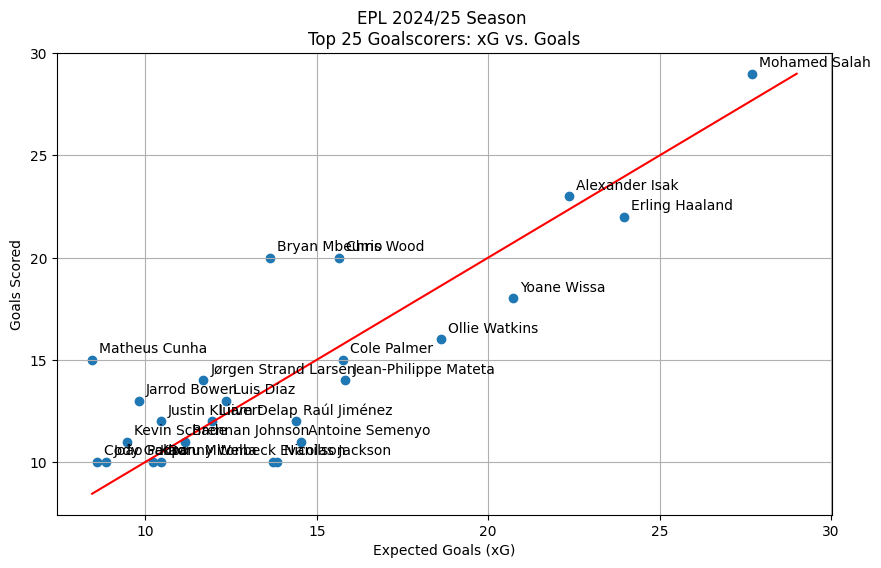

In [ ]:
if N <= player_data.shape[0]:
  plt.figure(figsize = (10, 6))
  plt.scatter(top_goalscorers['xG'], top_goalscorers['goals'])

  min_val = min(top_goalscorers['xG'].min(), top_goalscorers['goals'].min())
  max_val = max(top_goalscorers['xG'].max(), top_goalscorers['goals'].max())
  plt.plot([min_val, max_val], [min_val, max_val], 'r')

  plt.xlabel('Expected Goals (xG)')
  plt.ylabel('Goals Scored')
  plt.title(f'{league} {season}/{str(int(season[2:]) + 1)} Season \nTop {N} Goalscorers: xG vs. Goals')

  for i, row in top_goalscorers.iterrows():
      plt.annotate(row['player_name'], (row['xG'], row['goals']), textcoords = "offset points",
                  xytext = (5,5), ha = 'left')

  plt.grid(True)
  plt.show()
else:
  print(f"Please choose an N no more than {player_data.shape[0]}.")

In [ ]:
if N <= player_data.shape[0]:
  top_goalscorers['goals'] = pd.to_numeric(top_goalscorers['goals'], errors='coerce')
  top_goalscorers['shots'] = pd.to_numeric(top_goalscorers['shots'], errors='coerce')
  top_goalscorers['time'] = pd.to_numeric(top_goalscorers['time'], errors='coerce')

  for col in ['goals', 'shots', 'xG', 'time', 'games']:
      top_goalscorers[col] = pd.to_numeric(top_goalscorers[col], errors='coerce')

  top_goalscorers['goals_per_game'] = top_goalscorers['goals'] / top_goalscorers['games']
  top_goalscorers['xg_per_game'] = top_goalscorers['xG'] / top_goalscorers['games']
  top_goalscorers['minutes_per_game'] = top_goalscorers['time'] / top_goalscorers['games']
  top_goalscorers['shot_conversion_rate'] = (top_goalscorers['goals'] / top_goalscorers['shots']).fillna(0)
  top_goalscorers['games'] = top_goalscorers['time'] / 90

  fig = go.Figure()

  fig.add_trace(go.Scatter3d(
      x = top_goalscorers['xG'],
      y = top_goalscorers['goals'],
      z = top_goalscorers['time'],
      mode = 'markers+text',
      text = top_goalscorers['player_name'],
      customdata = top_goalscorers[['team_title']],
      name = 'Stats',
      marker = dict(
          size = top_goalscorers['goals'],
          color = top_goalscorers['shot_conversion_rate'],
          colorscale = 'Viridis',
          colorbar = dict(title='Conversion Rate'),
          opacity = 0.8
      ),
      hovertemplate = (
          "<b>%{text}</b><br>" +
          "Team: %{customdata[0]}<br><br>" +
          "<i>Season Stats:</i><br>" +
          "Goals: %{y:.1f}<br>" +
          "xG: %{x:.1f}<br>" +
          "Minutes: %{z:.0f}<br>" +
          "Conversion Rate: %{marker.color:.2f}<extra></extra>"
      )
  ))

  fig.add_trace(go.Scatter3d(
      x = [min_val, max_val],
      y = [min_val, max_val],
      z = [1500, 1500],
      mode = 'lines',
      name = 'xG = Goals',
      line = dict(color = 'blue', width = 4, dash='solid'),
      hoverinfo = 'skip',
      showlegend = True
  ))

  fig.add_trace(go.Scatter3d(
      x = [min_val, min_val],
      y = [min_val, max_val],
      z = [1500, 1500],
      mode = 'lines',
      line = dict(color = 'blue', width = 4, dash='solid'),
      hoverinfo = 'skip',
      showlegend = False
  ))

  fig.add_trace(go.Scatter3d(
      x = [min_val, max_val],
      y = [max_val, max_val],
      z = [1500, 1500],
      mode = 'lines',
      line = dict(color = 'blue', width = 4, dash='solid'),
      hoverinfo = 'skip',
      showlegend = False
  ))

  # Used to get upper bound for x & y axis range
  top_goalscorer = player_data.sort_values(by = 'goals', ascending = False).head(1)

  fig.update_layout(
      title = f'Top {N} Goalscorers for {league} {season}/{str(int(season[2:]) + 1)} Season: xG vs. Goals vs. Minutes Played',
      scene = dict(
          xaxis_title = 'Expected Goals (xG)',
          xaxis = dict(range=[0, top_goalscorer['xG'].max() + 10]),
          yaxis_title = 'Goals Scored',
          yaxis = dict(range=[0, top_goalscorer['goals'].max() + 10]),
          zaxis_title = 'Minutes Played',
          zaxis = dict(range=[1500, 4000])
      ),
      height = 800,
      hovermode = 'closest',
      legend = dict(
          orientation = 'h',
          yanchor = 'bottom',
          y = 0,
          xanchor = 'center',
          x = 0.5
      )
  )

  fig.show()
else:
  print(f"Please choose an N no more than {player_data.shape[0]}.")


 --------------------------------------------------------------------------------------------------------------------------------------------------
# Findings

Since there are multiple different graphs we can get (i.e. 5 leagues with 10 seasons each), each graph will look different.<br><br>


Because of this I have added a blue triangle which acts as a benchmark to visually assess finishing efficiency relative to xG. <br><br>

We see that on average, top goalscorers score about 1 in 5 attempted shots. <br><br>

Players within the triangle have scored more goals, or have score goals equal to their xG (overperformers), whereas players outside of the triangle have scored less goals than their xG (undererformers). Please note that being an overperformer/underperformer here is extremely subjective. A player could underperform their xG but still put up an above average amount of goals. Plus, there will be outliers. Thus the triangle is based on the average players seasonal performance.
<br>
<table>
  <thead>
    <tr>
      <th>Performance</th>
      <th>Description</th>
      <th>Interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Overperforming xG</strong></td>
      <td>Scoring more goals than expected based on shot quality (xG)</td>
      <td>
        <ul>
          <li>Very efficient finisher</li>
          <li>May score from low-probability shots</li>
          <li>Could involve luck or temporary form</li>
        </ul>
      </td>
    </tr>
    <tr>
      <td><strong>Underperforming xG</strong></td>
      <td>Scoring fewer goals than expected based on shot quality (xG)</td>
      <td>
        <ul>
          <li>Missing good chances</li>
          <li>Possibly unlucky or facing strong goalkeepers</li>
          <li>Could be in poor form</li>
        </ul>
      </td>
    </tr>
  </tbody>
</table>

Insights like this are how some coaching teams are able to determine which players they should keep in the first team and who should play, and also who needs more training or who should be sent down to play with the second team. Or let go from the team. Since we are looking here at top goalscorers, this would be refering more towards the first case. In a more detailed analysis, there may be separate lines for each player that show performances from previous seasons which could further be used to gauge performance.
